# K-Means clustering

In this notebook, we are going to look at how to do K-Means clustering in Python using Scikit-learn and other modules. Let us import the usual modules as well the `KMeans` model from Scikit-learn

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans

As example data, we will use some age and income data. The data is example data from the book ["Introduction to R for Business Intelligence"](https://jgendron.github.io/com.packtpub.intro.r.bi/), Packt Publishing Ltd., 2016, by Jay Gendron. The dataset is also on Moodle and can be loaded in by:

In [2]:
data = pd.read_csv("Ch5_age_income_data.csv")
data.head()

,bin,age,income
0,60-69,64,87083.236510
1,30-39,33,76807.824635
2,20-29,24,12043.598766
3,30-39,33,61972.002432
4,70-79,78,60120.315192


For our clustering, we will select only the `age` and the `income` variables:

In [3]:
X = data[['age', 'income']]

Here is an example of how to run K-Means clustering using `KMeans` with $K=3$:

In [4]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

C:\Users\jensuh\AppData\Local\miniconda3\envs\pydata-book-jan26\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


After calling the **fit()** function, the clustering is done, as it is *unsupervised* learning. The clustering result is stored in an array called **labels_**. It stores a cluster label for each data point in X.

In [5]:
kmeans.labels_

array([0, 1, 2, ..., 2, 2, 0], shape=(8105,), dtype=int32)

Each cluster's center (/centroid) is also stored, in another array called **cluster_centers_**:

In [6]:
kmeans.cluster_centers_

array([[3.81884969e+01, 1.02657793e+05],
       [4.62729513e+01, 6.87403238e+04],
       [4.23172043e+01, 3.62766927e+04]])

Let us now visualize the result of the clustering. To do this easily with Seaborn, we first a column with assigned cluster to the dataset:

In [7]:
data["3MeansCluster"] = kmeans.labels_

We can now plot the points of X together with their associated cluster and the cluster centroids:

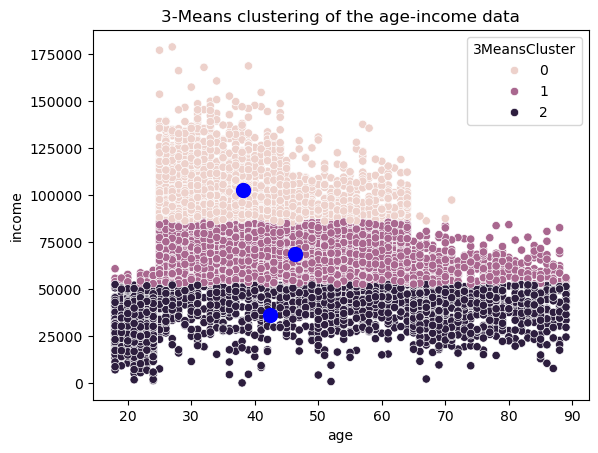

In [8]:
sns.scatterplot(data = data, x = "age", y = "income", hue = "3MeansCluster")
plt.scatter(x = kmeans.cluster_centers_[:,0], y = kmeans.cluster_centers_[:,1], color='blue', s = 100)
plt.title("3-Means clustering of the age-income data")
plt.show()

From the plot above we can see the data is not really clustered based on the two columns of Age and Income. It is only done on the Income that dominates the distance calculation. Therefore, we need to apply data scaling before we do clustering appropriately.

### Data Scaling

In [9]:
minMaxScaler = MinMaxScaler()
X_scaled_mm = pd.DataFrame(minMaxScaler.fit_transform(X), columns=X.columns)

We can now build the 3-means clustering model again:

In [10]:
kmeans_scaled = KMeans(n_clusters=3)
kmeans_scaled.fit(X_scaled_mm)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Let us visualize clustering with the scaling also:

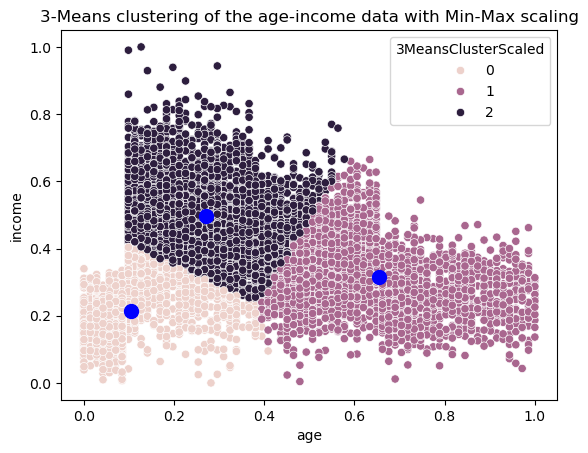

In [11]:
data_scaled = X_scaled_mm.copy()
data_scaled["3MeansClusterScaled"] = kmeans_scaled.labels_

sns.scatterplot(data = data_scaled, x = "age", y = "income", hue = "3MeansClusterScaled")
plt.scatter(x = kmeans_scaled.cluster_centers_[:,0], y = kmeans_scaled.cluster_centers_[:,1], color='blue', s = 100)
plt.title("3-Means clustering of the age-income data with Min-Max scaling")
plt.show()

If we want a plot of the point that are not scaled, we can simply add the clustering information to the original dataset `data` as before:

In [12]:
data["3MeansClusterScaled"] = kmeans_scaled.labels_

However, our cluster centroids are scalled, so we need to rescale them to plot those also:

In [13]:
centroids = minMaxScaler.inverse_transform(kmeans_scaled.cluster_centers_)

We can now plot the unscaled data with the clusters generated from the scaled data:

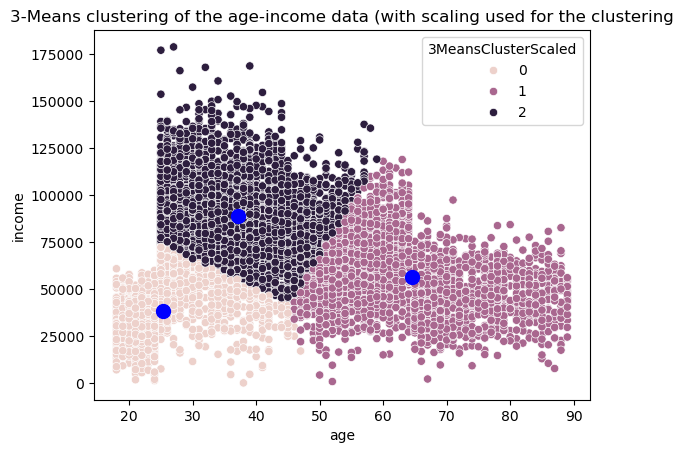

In [14]:
sns.scatterplot(data = data, x = "age", y = "income", hue = "3MeansClusterScaled")
plt.scatter(x = centroids[:,0], y = centroids[:,1], color='blue', s = 100)
plt.title("3-Means clustering of the age-income data (with scaling used for the clustering")
plt.show()

### The Elbow Method

We can try different K values and plot the SSEs for all of them. From the plot, we can choose the Elbow Point, i.e., the best K.

We generate a series K-Means models by varying K from 1 to 20. A model's variable **inertia_** stores the overall SSE (sum of squared error) for the model.

In [15]:
errors = []
K = range(1, 20)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X_scaled_mm)
    errors.append(kmeanModel.inertia_)

We plot the (K, SSE) pairs for all Ks:

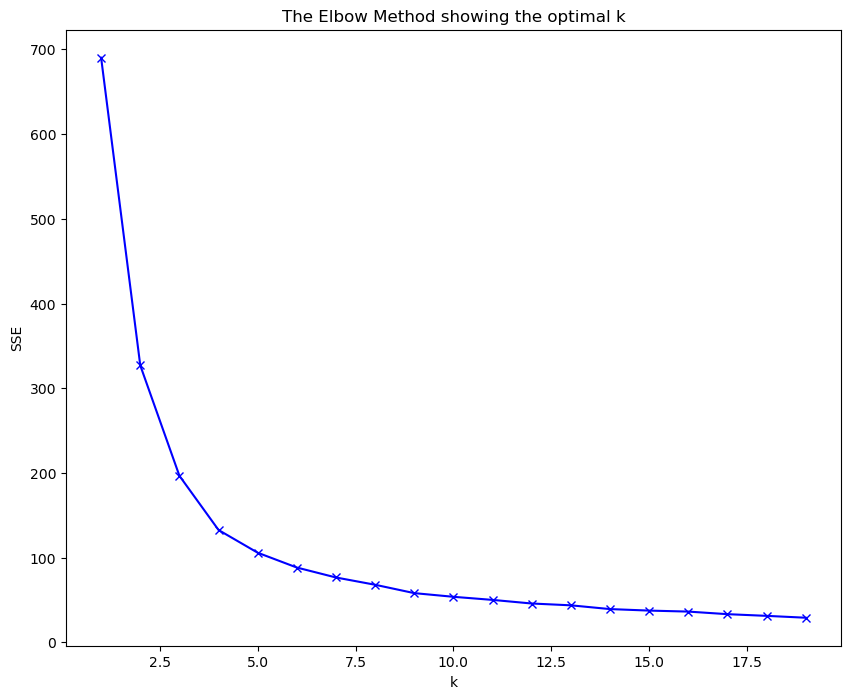

In [16]:
plt.figure(figsize=(10, 8))
plt.plot(K, errors, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('The Elbow Method showing the optimal k')
plt.show()

Let's take a closer look by printing out the SSE decrease for each K:

In [17]:
for i in range(1, len(errors)):
    print('K={0}: {1}'.format(i+1, errors[i-1] - errors[i]))

K=2: 363.2115713132468
K=3: 130.3007462002206
K=4: 63.9955361526973
K=5: 26.811148229533714
K=6: 17.483263133759394
K=7: 11.746590694667589
K=8: 8.589521627065295
K=9: 9.871790714598447
K=10: 4.334552133804813
K=11: 3.657464687584394
K=12: 4.253925513863869
K=13: 2.146993474496661
K=14: 4.434036458696447
K=15: 1.7876180424895551
K=16: 1.1750319819114736
K=17: 3.0455122573414357
K=18: 1.9944050341546458
K=19: 2.202455248368473


In this case, it looks like we should choose K=5, 6, or 7.

Let us try with k=7, for instance:

In [18]:
kmeans_scaled7 = KMeans(n_clusters=7)
kmeans_scaled7.fit(X_scaled_mm)

data["7MeansClusterScaled"] = kmeans_scaled7.labels_
centroids7 = minMaxScaler.inverse_transform(kmeans_scaled7.cluster_centers_)

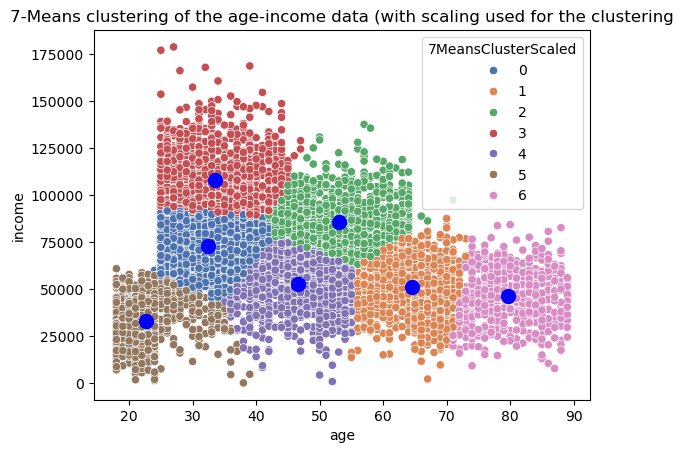

In [19]:
sns.scatterplot(data = data, x = "age", y = "income", hue = "7MeansClusterScaled", palette="deep")
plt.scatter(x = centroids7[:,0], y = centroids7[:,1], color='blue', s = 100)
plt.title("7-Means clustering of the age-income data (with scaling used for the clustering")
plt.show()